In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
births = pd.read_csv('./births.csv', index_col='Date', parse_dates=['Date'])
passengers = pd.read_csv('./passengers.csv', index_col='Month', parse_dates=['Month'])

In [3]:
births.head()

,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


In [4]:
passengers.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
passengers.resample(rule='YS').mean().head()

,#Passengers
Month,
1949-01-01,126.666667
1950-01-01,139.666667
1951-01-01,170.166667
1952-01-01,197.000000
1953-01-01,225.000000


In [6]:
passengers.rolling(window=3).mean().head(10)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,120.666667
1949-04-01,126.333333
1949-05-01,127.333333
1949-06-01,128.333333
1949-07-01,134.666667
1949-08-01,143.666667
1949-09-01,144.000000


<Axes: xlabel='Month'>

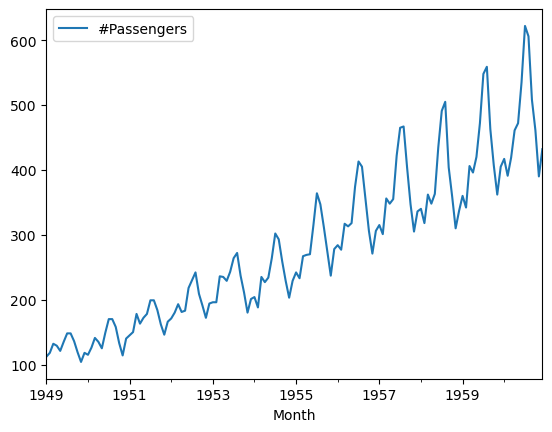

In [7]:
passengers.plot()

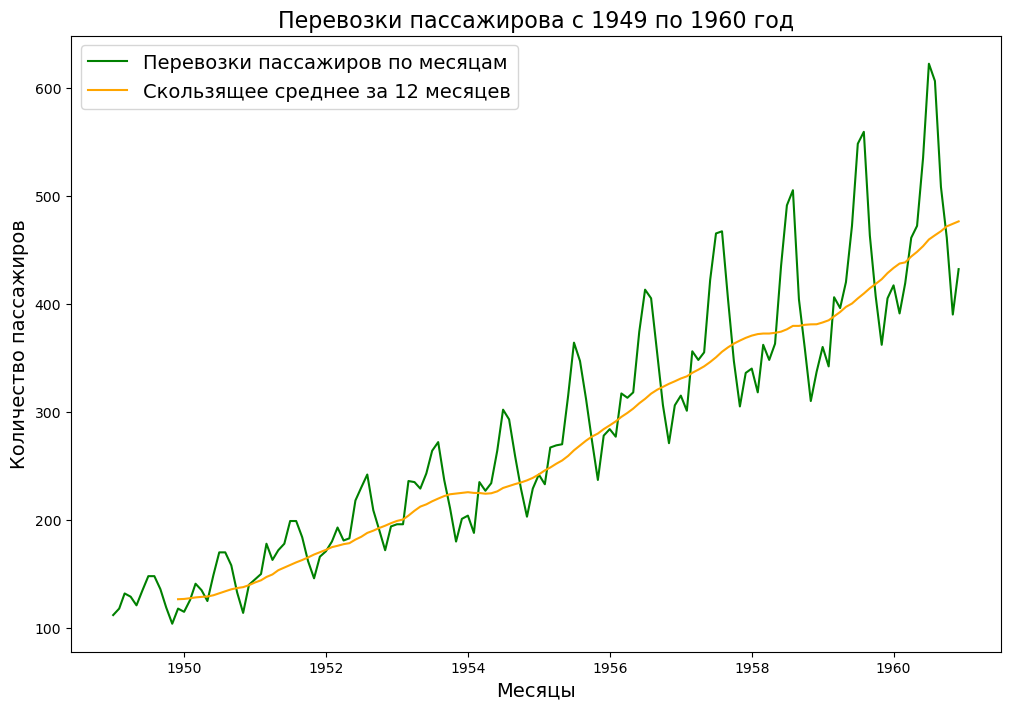

In [8]:
plt.figure(figsize=(12,8))

plt.plot(passengers, label = 'Перевозки пассажиров по месяцам', color='green')
plt.plot(passengers.rolling(window=12).mean(), label='Скользящее среднее за 12 месяцев', color='orange')

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Месяцы', fontsize=14)
plt.ylabel('Количество пассажиров', fontsize=14)
plt.title('Перевозки пассажирова с 1949 по 1960 год', fontsize=16)

plt.show()

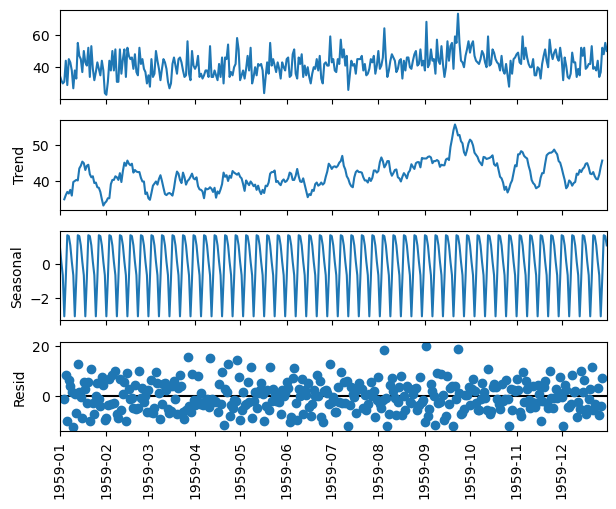

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(births)
decompose.plot()
plt.xticks(rotation=90)
plt.show()

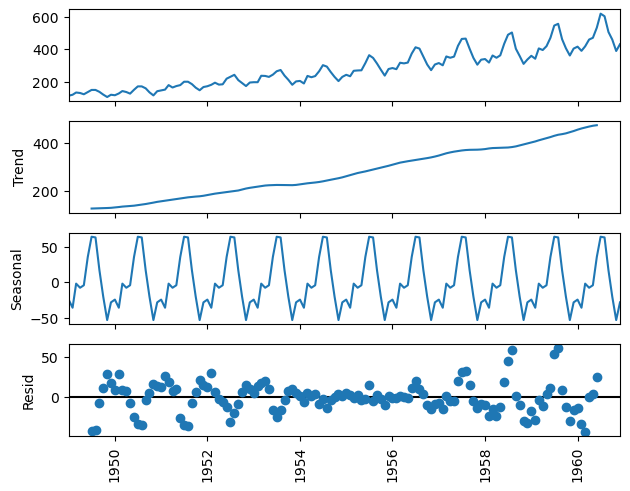

In [10]:
decompose = seasonal_decompose(passengers)
decompose.plot()
plt.xticks(rotation=90)
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

adf_test=adfuller(passengers['#Passengers'])

print('p-value = ' + str(adf_test[1])) ##нестационарен

p-value = 0.991880243437641


In [12]:
adf_test=adfuller(births['Births'])
print('p-value = ' + str(adf_test[1])) ##стационарен

p-value = 5.2434129901498554e-05


In [13]:
shift_1 = passengers["#Passengers"][1:]
np.round(np.corrcoef(passengers["#Passengers"][:-1], shift_1)[0,1],2)

np.float64(0.96)

Вся положительная автокорреляция свидетельствует о наличии тренда. 

Колебание автокорреляции в 11-12 лаге может говорить о сезонности

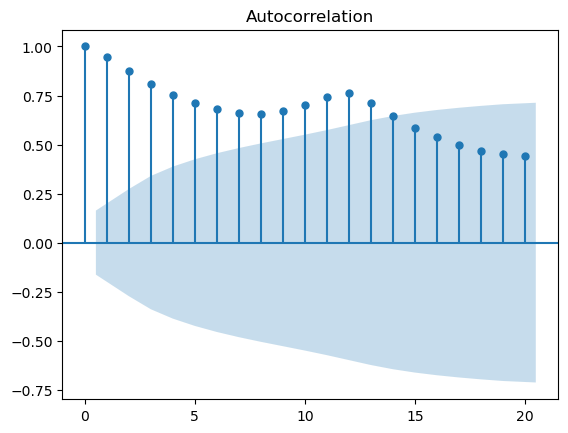

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(passengers['#Passengers'], lags =20)
plt.axis('tight')
plt.show()

Значения автокорреляции значительно ниже, есть отрицательные, поэтому можно сказать, что тренда и сезонности нет

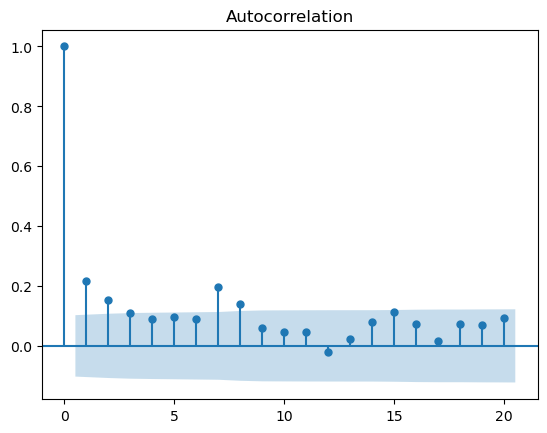

In [15]:
plot_acf(births['Births'], lags=20)
plt.axis('tight')
plt.show()

Экспоненциальное сглаживание

<small>Берем все предыдущие значения и задаем каждому вес, который экспоненциально уменьшается по мере углубления в прошлое</small>

In [16]:
passengers = pd.read_csv('./passengers.csv', parse_dates=['Month'])

In [17]:
from statsmodels.tsa.api import ExponentialSmoothing
train_data = passengers['#Passengers'][:120]
test_data = passengers['#Passengers'][120:]

model = ExponentialSmoothing(train_data, trend='add', seasonal='add', seasonal_periods=12)

model_fit = model.fit()

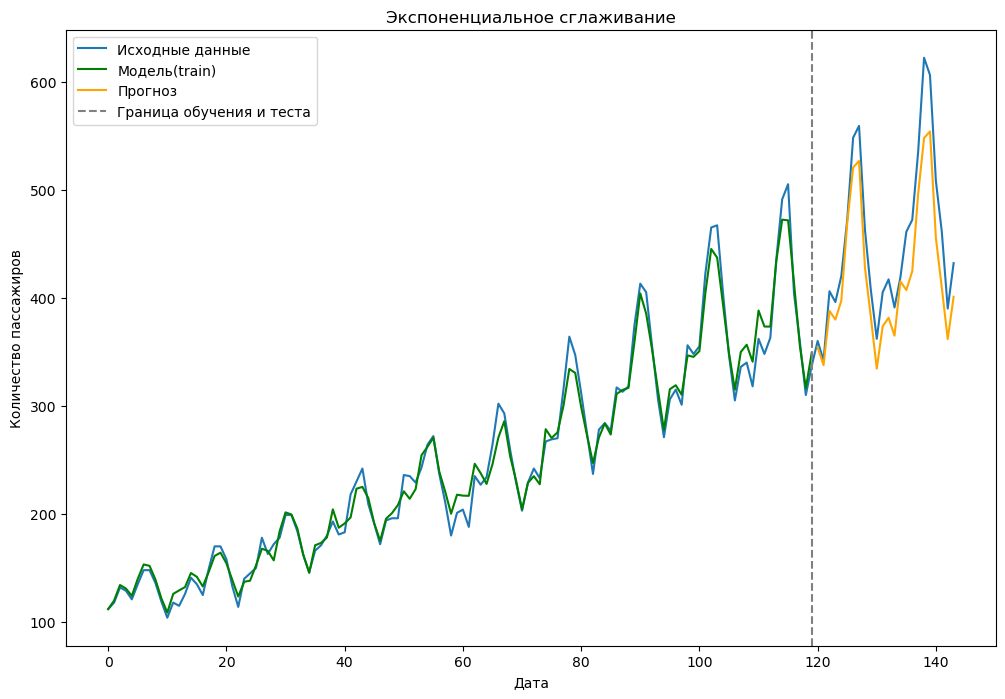

In [18]:
forecast = model_fit.forecast(len(test_data))

plt.figure(figsize=(12,8))
plt.plot(passengers.index, passengers['#Passengers'], label='Исходные данные')
plt.plot(train_data.index, model_fit.fittedvalues, label='Модель(train)', color='green')
plt.plot(test_data.index, forecast, label='Прогноз', color='orange')
plt.axvline(x=train_data.index[-1], linestyle='--', color='gray', label='Граница обучения и теста')

plt.legend()
plt.title('Экспоненциальное сглаживание')
plt.xlabel('Дата')
plt.ylabel("Количество пассажиров")
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_data, forecast)
mse = mean_squared_error(test_data, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(test_data - forecast)/test_data)*100

print("Метрики качества: ")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}")

Метрики качества: 
MAE: 31.08
MSE: 1278.95
RMSE: 35.76
MAPE: 6.64


SARIMAX = Авторегрессия + Скользящее среднее + тренд + сезонность + экзогенные факторы

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

data = passengers.copy()
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

train_data = data['#Passengers'][:-12]
test_data = data['#Passengers'][-12:]

In [30]:
model=SARIMAX(train_data,
             order = (1, 1, 1), #ARIMA(p, d, q)
             seasonal_order=(1, 1 , 1, 12), #SARIMA(P, D, Q, S)
             enforce_stationarity=False,
             enforce_invertibility=False)   

sarima_result = model.fit(disp=False)

In [31]:
forecast=sarima_result.forecast(steps=12)

mae = mean_absolute_error(test_data, forecast)
mse = mean_squared_error(test_data, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(test_data-forecast) / test_data) * 100

print('Метрики качества: ')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

Метрики качества: 
MAE: 16.67
MSE: 467.48
RMSE: 21.62
MAPE: 3.76%


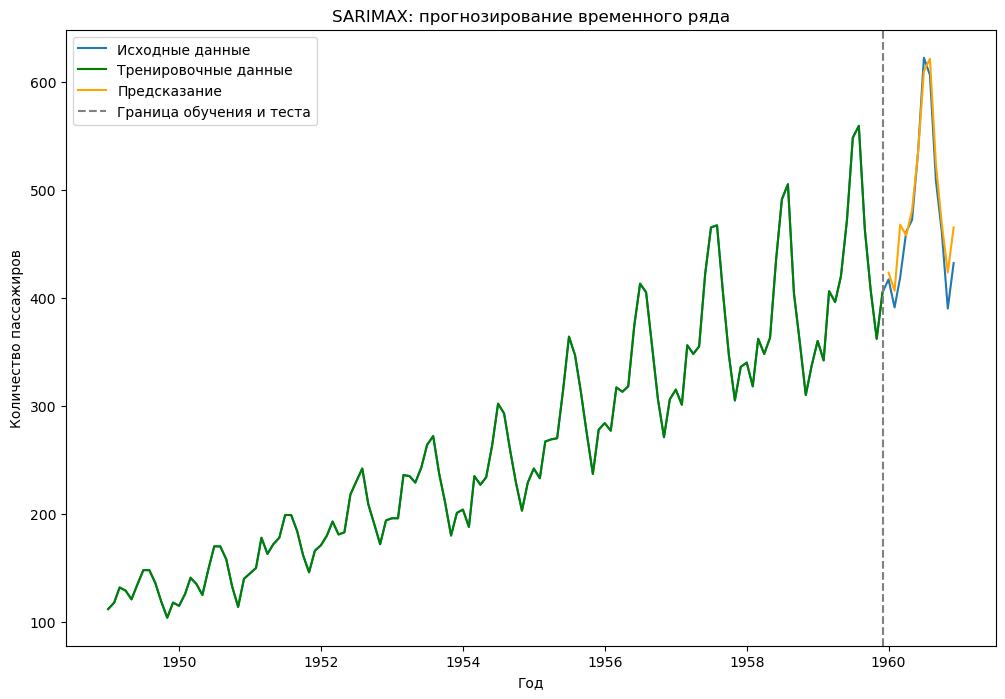

In [32]:
plt.figure(figsize=(12,8))
plt.plot(data, label='Исходные данные')
plt.plot(train_data, label='Тренировочные данные', color='green')
plt.plot(forecast, label='Предсказание', color='orange')
plt.axvline(train_data.index[-1], color='gray', linestyle='--', label='Граница обучения и теста')

plt.legend()
plt.title('SARIMAX: прогнозирование временного ряда')
plt.xlabel('Год')
plt.ylabel('Количество пассажиров')
plt.show()

In [33]:
from pmdarima import auto_arima

auto_model = auto_arima(train_data, seasonal=True, m=12, trace=False)
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -447.843
Date:                            Sat, 09 May 2026   AIC                            905.686
Time:                                    12:46:42   BIC                            919.623
Sample:                                01-01-1949   HQIC                           911.346
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.5341      2.007      2.757      0.006       1.600       9.468
ar.L1          0.7049      0.095      7.393      0.000       0.518       0.892
ar.L2          0.2574      0.131      1.968      0.049       0.001       0.514
ar.L3         -0.1434      0.107     -1.338      0.181      -0.354       0.067
sigma2       101.0969     12.818      7.887      0.000      75.974     126.220
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.83
Prob(Q):                              0.96   Prob(JB):                         0.24
Heteroskedasticity (H):               1.41   Skew:                            -0.14
Prob(H) (two-sided):                  0.29   Kurtosis:                         3.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [34]:
model=SARIMAX(train_data,
             order = (3, 0, 0), 
             seasonal_order=(0, 1 , 0, 12),
             enforce_stationarity=False,
             enforce_invertibility=False)   

sarima_result = model.fit(disp=False)

In [35]:
forecast=sarima_result.forecast(steps=12)

mae = mean_absolute_error(test_data, forecast)
mse = mean_squared_error(test_data, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(test_data-forecast) / test_data) * 100

print('Метрики качества: ')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

Метрики качества: 
MAE: 14.32
MSE: 370.29
RMSE: 19.24
MAPE: 3.22%


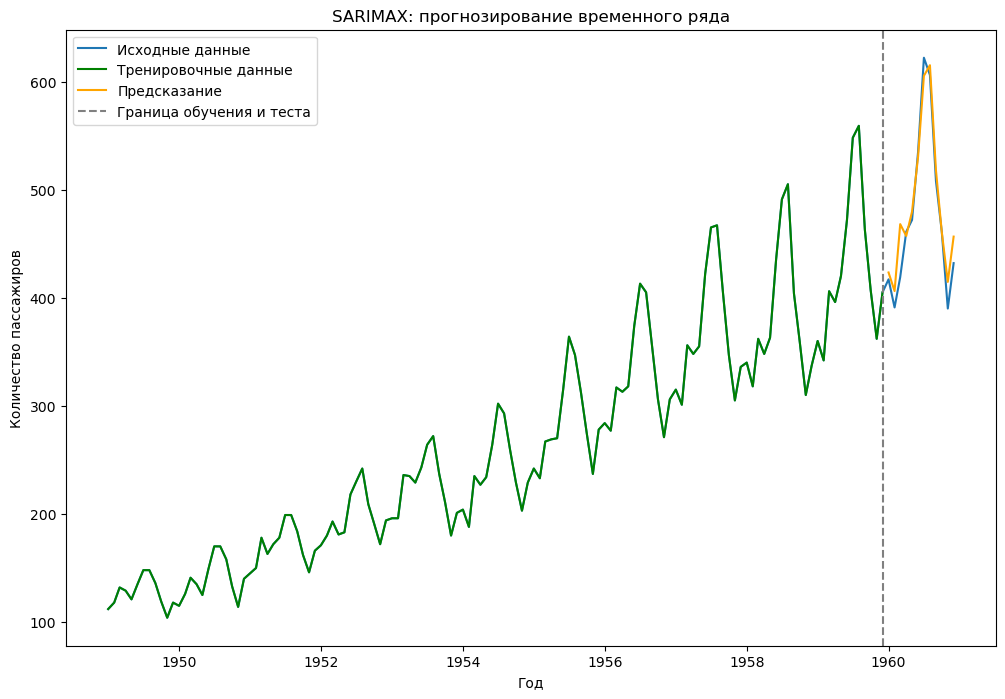

In [36]:
plt.figure(figsize=(12,8))
plt.plot(data, label='Исходные данные')
plt.plot(train_data, label='Тренировочные данные', color='green')
plt.plot(forecast, label='Предсказание', color='orange')
plt.axvline(train_data.index[-1], color='gray', linestyle='--', label='Граница обучения и теста')

plt.legend()
plt.title('SARIMAX: прогнозирование временного ряда')
plt.xlabel('Год')
plt.ylabel('Количество пассажиров')
plt.show()